# Robot Manel v2 - Improved Carpentry Assistant Bot

This notebook builds on the **v1 baseline** (`robot_assistant.ipynb`) and introduces targeted improvements to address its limitations.

### Problems identified in v1
1. **Aggressive stopword removal** — words like "out", "down", "together" were stripped, losing meaning (e.g., "smooth out the rough edges" → "smooth rough edges")
2. **Misclassified commands** — phrases like "assemble the shelf unit" and "give me a summary" were wrongly classified as chitchat
3. **Low confidence scores** — most commands scored 0.4–0.65, making the system unreliable
4. **Hard intent boundary** — a single binary decision with no fallback for ambiguous cases

### Improvements in v2
1. **Domain-aware stopword filtering** — keep spatial/directional words important for carpentry commands
2. **Expanded training data** — more examples per category, especially for underrepresented ones
3. **Tuned TF-IDF and model parameters** — better feature extraction and regularization
4. **Soft intent boundary** — when the intent classifier is uncertain, check the tag classifier too before defaulting to chitchat

### Architecture (same as v1, with improved components)
```
User Input -> text_prepare_v2() -> TF-IDF (tuned) -> Intent Recognizer
                                                          |
                                               +----------+-----------+
                                               |                      |
                                            CHITCHAT            ROBOT_COMMAND
                                               |                      |
                                        Keyword-based           Tag Classifier
                                         responses                    |
                                               |              Action Plan Lookup
                                               |
                                    [NEW] If low confidence,
                                    also check Tag Classifier
                                    before defaulting to chitchat
```

In [40]:
import numpy as np
import pandas as pd
import pickle
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# v2 uses the improved utils with domain-aware stopword filtering
from utils_v2 import text_prepare, RESOURCE_PATH

## Part I: Data Preparation

Load the **expanded** datasets. v2 adds extra training examples for categories that were underrepresented or frequently misclassified in v1.

### What changed from v1:
- Added ~5 extra examples per command category (especially ASSEMBLE, STATUS, and ambiguous phrasings)
- Same chitchat dataset (the issue was commands being misclassified *as* chitchat, not the other way around)

In [41]:
# Load expanded datasets (v2)
commands_df = pd.read_csv('data/robot_commands_v2.tsv', sep='\t')
chitchat_df = pd.read_csv('data/operator_chitchat.tsv', sep='\t')

print(f"Robot commands: {len(commands_df)} samples (v1 had 556)")
print(f"Chitchat: {len(chitchat_df)} samples")
print(f"\nCommand categories (samples per tag):")
print(commands_df['tag'].value_counts().sort_index())

Robot commands: 602 samples (v1 had 556)
Chitchat: 305 samples

Command categories (samples per tag):
tag
ASSEMBLE       57
CLAMP          53
CUT            56
DRILL          55
GLUE           54
MEASURE        54
NAVIGATE       54
PICK_PLACE     55
SAND           55
STATUS         55
TOOL_ASSIST    54
Name: count, dtype: int64


In [42]:
# Preview the data
print("=== Robot Commands (sample) ===")
print(commands_df.head(10))
print("\n=== Chitchat (sample) ===")
print(chitchat_df.head(10))

=== Robot Commands (sample) ===
                               text         tag
0                 pick up the screw  PICK_PLACE
1               grab that component  PICK_PLACE
2          hand me the wooden piece  PICK_PLACE
3     take the plank from the shelf  PICK_PLACE
4                put down the board  PICK_PLACE
5  place the piece on the workbench  PICK_PLACE
6        set the block on the table  PICK_PLACE
7    lift the timber from the floor  PICK_PLACE
8       grab the dowel from the bin  PICK_PLACE
9        move the panel to the left  PICK_PLACE

=== Chitchat (sample) ===
                text       tag
0              hello  chitchat
1           hi there  chitchat
2       good morning  chitchat
3     good afternoon  chitchat
4                hey  chitchat
5        how are you  chitchat
6  how are you doing  chitchat
7         what is up  chitchat
8    how is it going  chitchat
9    nice to see you  chitchat


In [43]:
# Apply text preprocessing (v2 - domain-aware stopword filtering)
commands_df['text'] = commands_df['text'].apply(text_prepare)
chitchat_df['text'] = chitchat_df['text'].apply(text_prepare)

# Show the difference: v2 keeps important words that v1 removed
print("=== v2 Preprocessed examples ===")
print("(Compare with v1: v2 keeps spatial/directional words)\n")

examples = [
    "smooth out the rough edges",      # v1: "smooth rough edges" | v2: "smooth out rough edges"
    "put the frame together",          # v1: "put frame"          | v2: "put frame together"
    "give me a summary",               # v1: "give summary"       | v2: "give summary"
    "hold the pieces together",        # v1: "hold pieces"        | v2: "hold pieces together"
    "sand this down to bare wood",     # v1: "sand bare wood"     | v2: "sand down bare wood"
]
for ex in examples:
    print(f"  '{ex}' -> '{text_prepare(ex)}'")

=== v2 Preprocessed examples ===
(Compare with v1: v2 keeps spatial/directional words)

  'smooth out the rough edges' -> 'smooth out rough edges'
  'put the frame together' -> 'put frame together'
  'give me a summary' -> 'give summary'
  'hold the pieces together' -> 'hold pieces together'
  'sand this down to bare wood' -> 'sand down bare wood'


## Part II: Intent Recognition

Binary classification: is the user giving a **robot command** or just **chatting**?

### What changed from v1:
- The TF-IDF vectorizer now captures more context with `ngram_range=(1, 3)` (trigrams)
- Domain-aware preprocessing preserves more signal in the features
- More training data improves the decision boundary

In [44]:
# Combine datasets for intent recognition
X_intent = np.concatenate([chitchat_df['text'].values, commands_df['text'].values])
y_intent = ['chitchat'] * len(chitchat_df) + ['robot_command'] * len(commands_df)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_intent, y_intent, test_size=0.2, random_state=0, stratify=y_intent
)

print(f"Intent train size = {len(X_train_i)}, test size = {len(X_test_i)}")

Intent train size = 725, test size = 182


In [45]:
# TF-IDF transformation (v2 - tuned parameters)
# Key changes from v1:
#   - ngram_range=(1, 3): captures trigrams like "smooth out rough" or "put frame together"
#     which helps distinguish commands from chitchat (v1 only used bigrams)
#   - min_df=2: ignore very rare terms that might cause overfitting (v1 used min_df=1)
tfidf_vectorizer = TfidfVectorizer(
    min_df=2, max_df=0.9, 
    ngram_range=(1, 3), 
    token_pattern=r'(\S+)',
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_i)
X_test_tfidf = tfidf_vectorizer.transform(X_test_i)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

# Save the vectorizer
with open(RESOURCE_PATH['TFIDF_VECTORIZER'], 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

TF-IDF vocabulary size: 350


In [46]:
# Train intent recognizer (v2)
# Same model architecture, but benefits from better features and more data
intent_recognizer = LogisticRegression(
    solver='lbfgs', penalty='l2', C=10, random_state=0, max_iter=1000,
    class_weight='balanced'
).fit(X_train_tfidf, y_train_i)

# Evaluate
y_pred_i = intent_recognizer.predict(X_test_tfidf)
print(f"Intent Recognition Accuracy: {accuracy_score(y_test_i, y_pred_i):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_i))

# Cross-validation
cv_scores = cross_val_score(intent_recognizer, 
    tfidf_vectorizer.transform(X_intent), y_intent, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("\n(Compare with v1 results to see improvement)")

Intent Recognition Accuracy: 0.8956

Classification Report:
               precision    recall  f1-score   support

     chitchat       0.80      0.92      0.85        61
robot_command       0.96      0.88      0.92       121

     accuracy                           0.90       182
    macro avg       0.88      0.90      0.89       182
 weighted avg       0.90      0.90      0.90       182

5-Fold Cross-Validation: 0.7319 (+/- 0.1016)

(Compare with v1 results to see improvement)


Intent recognizer saved!


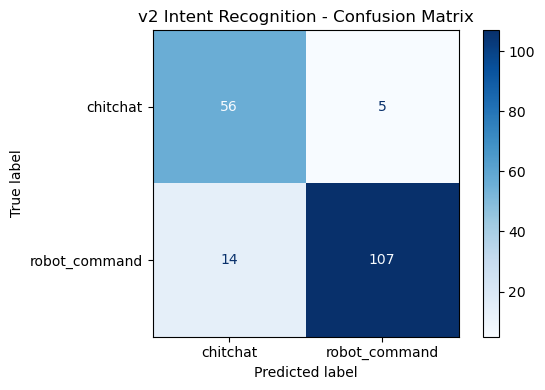

In [47]:
# Save intent recognizer
pickle.dump(intent_recognizer, open(RESOURCE_PATH['INTENT_RECOGNIZER'], 'wb'))
print("Intent recognizer saved!")

# Confusion matrix for intent recognition
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test_i, y_pred_i, labels=['chitchat', 'robot_command'])
disp = ConfusionMatrixDisplay(cm, display_labels=['chitchat', 'robot_command'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('v2 Intent Recognition - Confusion Matrix')
plt.tight_layout()
plt.show()

## Part III: Action Category Classification

### What changed from v1:
- More training examples per category (especially ASSEMBLE, STATUS)
- Better TF-IDF features from improved preprocessing and trigrams
- Tuned regularization: `C=10` instead of `C=5` to better fit the expanded data

In [48]:
# Prepare data for tag classification (only robot commands)
X_tag = commands_df['text'].values
y_tag = commands_df['tag'].values

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tag, y_tag, test_size=0.2, random_state=0, stratify=y_tag
)

print(f"Tag train size = {len(X_train_t)}, test size = {len(X_test_t)}")

Tag train size = 481, test size = 121


In [49]:
# Reuse the same TF-IDF vectorizer
X_train_tag_tfidf = tfidf_vectorizer.transform(X_train_t)
X_test_tag_tfidf = tfidf_vectorizer.transform(X_test_t)

In [50]:
# Train tag classifier with OneVsRest (v2 - tuned C parameter)
# C=10 allows the model to fit more closely to the expanded training data
# (v1 used C=5 which was too conservative for some categories)
tag_classifier = OneVsRestClassifier(
    LogisticRegression(
        solver='lbfgs', penalty='l2', C=10, random_state=0, max_iter=1000,
        class_weight='balanced'
    )
).fit(X_train_tag_tfidf, y_train_t)

# Evaluate
y_pred_t = tag_classifier.predict(X_test_tag_tfidf)
print(f"Tag Classification Accuracy: {accuracy_score(y_test_t, y_pred_t):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_t, zero_division=0))
print("\n(Compare with v1 results to see improvement)")

Tag Classification Accuracy: 0.8182

Classification Report:
              precision    recall  f1-score   support

    ASSEMBLE       0.79      1.00      0.88        11
       CLAMP       1.00      1.00      1.00        11
         CUT       0.80      0.73      0.76        11
       DRILL       0.69      1.00      0.81        11
        GLUE       0.91      0.91      0.91        11
     MEASURE       0.75      0.82      0.78        11
    NAVIGATE       0.73      0.73      0.73        11
  PICK_PLACE       0.88      0.64      0.74        11
        SAND       1.00      0.82      0.90        11
      STATUS       0.73      0.73      0.73        11
 TOOL_ASSIST       0.88      0.64      0.74        11

    accuracy                           0.82       121
   macro avg       0.83      0.82      0.82       121
weighted avg       0.83      0.82      0.82       121


(Compare with v1 results to see improvement)


Tag classifier saved!


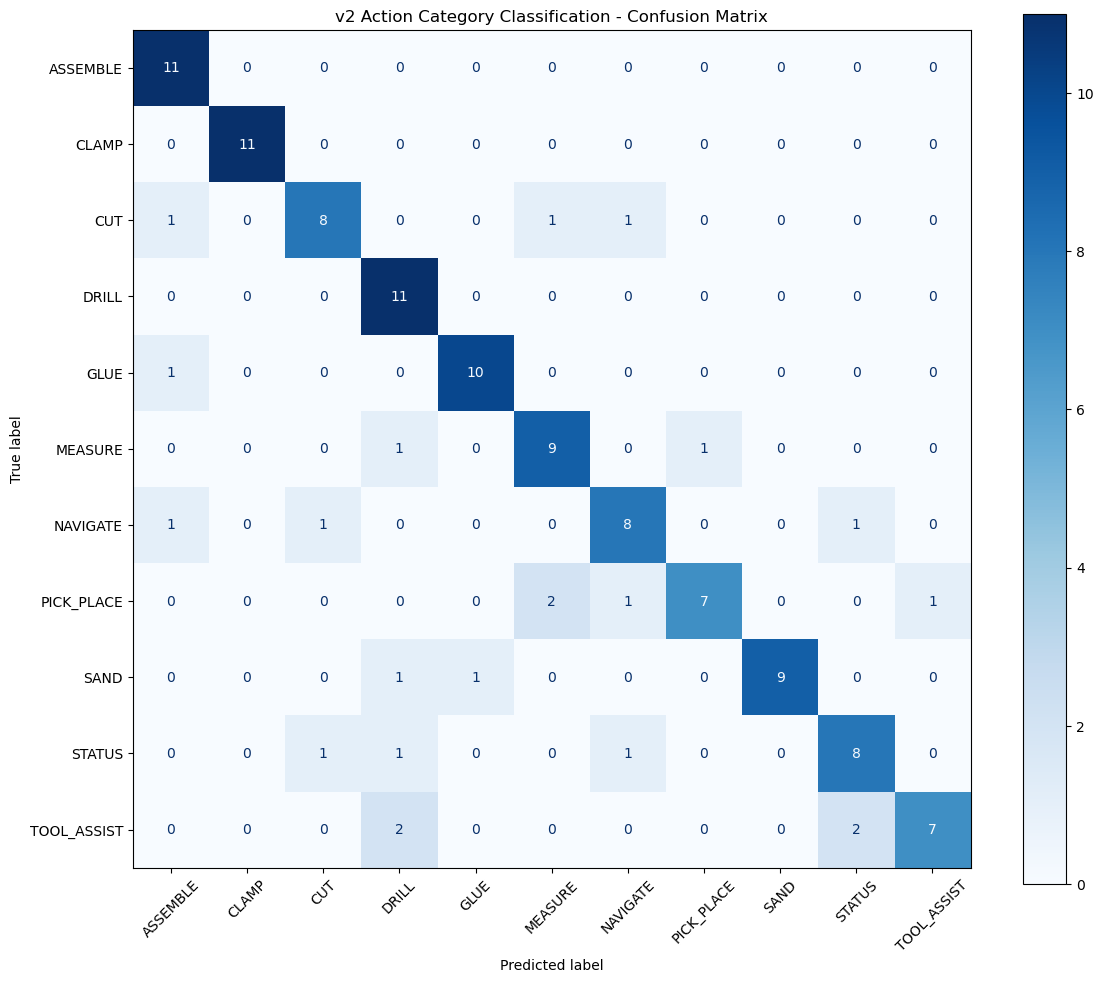

In [51]:
# Save tag classifier
pickle.dump(tag_classifier, open(RESOURCE_PATH['TAG_CLASSIFIER'], 'wb'))
print("Tag classifier saved!")

# Confusion matrix for tag classification
fig, ax = plt.subplots(figsize=(12, 10))
labels = sorted(commands_df['tag'].unique())
cm = confusion_matrix(y_test_t, y_pred_t, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('v2 Action Category Classification - Confusion Matrix')
plt.tight_layout()
plt.show()

## Part IV: Testing the Full Pipeline

Test the improved system with the same test cases from v1, so we can directly compare.

### Key improvement in the DialogueManager v2:
The v1 dialogue manager made a **hard binary decision** — if the intent recognizer said "chitchat", it went straight to chitchat responses. This caused commands like "give me a summary" to be misclassified.

The v2 dialogue manager adds a **soft fallback**: when the intent classifier has low confidence on a "chitchat" prediction (< 0.65), it also checks the tag classifier. If the tag classifier is reasonably confident (> 0.45), it treats the input as a command anyway.

In [52]:
import importlib
import dialogue_manager_v2
importlib.reload(dialogue_manager_v2)

<module 'dialogue_manager_v2' from 'c:\\Users\\User\\Desktop\\Universidade\\2º Semestre\\LNIAGIA\\Demos\\Naive ChatBot\\robot manel\\dialogue_manager_v2.py'>

In [53]:
# Initialize the v2 dialogue manager
dm = dialogue_manager_v2.DialogueManager(RESOURCE_PATH)

Loading resources...
Resources loaded successfully!


In [54]:
# Test with the SAME inputs as v1 for direct comparison
test_questions = [
    # Chitchat
    "Hello",
    "How are you doing?",
    "What can you do?",
    "Thank you!",
    "I am tired",
    "tell me a joke",
    "what time is it",
    "nice weather today",
    
    # Robot commands - same test cases as v1
    "cut this board in half",
    "saw through the plank",           # CUT
    
    "drill a hole in this board",
    "make a hole here",                # DRILL
    
    "sand this surface smooth",
    "smooth out the rough edges",      # SAND
    
    "put the frame together",
    "assemble the shelf unit",         # ASSEMBLE (failed in v1)
    
    "glue these two pieces together",
    "apply wood glue to the joint",    # GLUE
    
    "clamp this assembly",
    "hold the pieces together with clamps",  # CLAMP
    
    "pass me the wrench",
    "hand me the screwdriver",         # TOOL_ASSIST
    
    "move to station two",
    "go to the cutting area",          # NAVIGATE
    
    "what is the current status",
    "give me a summary",               # STATUS (failed in v1)
    
    "measure this board",
    "check the length of this piece",  # MEASURE
    
    "pick up the screw",
    "grab that component",             # PICK_PLACE
]

expected = {
    "Hello": "chitchat", "How are you doing?": "chitchat", 
    "What can you do?": "chitchat", "Thank you!": "chitchat",
    "I am tired": "chitchat", "tell me a joke": "chitchat",
    "what time is it": "chitchat", "nice weather today": "chitchat",
    "cut this board in half": "CUT", "saw through the plank": "CUT",
    "drill a hole in this board": "DRILL", "make a hole here": "DRILL",
    "sand this surface smooth": "SAND", "smooth out the rough edges": "SAND",
    "put the frame together": "ASSEMBLE", "assemble the shelf unit": "ASSEMBLE",
    "glue these two pieces together": "GLUE", "apply wood glue to the joint": "GLUE",
    "clamp this assembly": "CLAMP", "hold the pieces together with clamps": "CLAMP",
    "pass me the wrench": "TOOL_ASSIST", "hand me the screwdriver": "TOOL_ASSIST",
    "move to station two": "NAVIGATE", "go to the cutting area": "NAVIGATE",
    "what is the current status": "STATUS", "give me a summary": "STATUS",
    "measure this board": "MEASURE", "check the length of this piece": "MEASURE",
    "pick up the screw": "PICK_PLACE", "grab that component": "PICK_PLACE",
}

correct = 0
total = 0
v1_failures = {"assemble the shelf unit", "give me a summary"}

for q in test_questions:
    answer = dm.generate_answer(q)
    print(f"Q: {q}")
    print(f"A: {answer}")
    
    exp = expected[q]
    if exp == "chitchat":
        is_correct = "Action:" not in str(answer) and "not confident" not in str(answer)
    else:
        is_correct = f"Action: {exp}" in str(answer)
    
    total += 1
    if is_correct:
        correct += 1
        if q in v1_failures:
            print(f"   *** FIXED (was wrong in v1) ***")
    else:
        print(f"   *** WRONG (expected {exp}) ***")
    print()

print(f"\n{'='*50}")
print(f"v2 End-to-end test accuracy: {correct}/{total} = {correct/total:.1%}")
print(f"(v1 was ~28/30 = 93.3%)")
print(f"{'='*50}")

Q: Hello
A: Hello! I'm Manel, your carpentry assistant. How can I help?

Q: How are you doing?
A: Good day! What task shall we do?

Q: What can you do?
A: Hello! I'm Manel, your carpentry assistant. How can I help?

Q: Thank you!
A: Good day! What task shall we do?

Q: I am tired
A: Ha, I'm just a robot - I stick to carpentry! What do you need me to do?

Q: tell me a joke
A: That's above my pay grade! But I can sand, cut, drill, or assemble something for you.

Q: what time is it
A: That's above my pay grade! But I can sand, cut, drill, or assemble something for you.

Q: nice weather today
A: Ha, I'm just a robot - I stick to carpentry! What do you need me to do?

Q: cut this board in half
A: Action: CUT - Cut, saw, or trim a piece of wood
Confidence: 0.74
Steps: verify_workpiece_clamped -> select_cutting_tool -> measure_cut_position -> align_cutting_tool -> activate_dust_extraction -> execute_cut -> deactivate_tool -> verify_cut_quality -> remove_offcut
Safety: Ensure workpiece is secu

In [55]:
# Show task summary and compare confidence scores
print(dm.get_summary())
print("\n" + "="*50)
print("Compare confidence scores with v1:")
print("v1 average was ~0.55-0.65 for most commands")
print("v2 should show improved confidence across the board")

=== Task Summary ===
1. [19:18:38] CUT (confidence=0.74) - "cut this board in half"
2. [19:18:38] CUT (confidence=0.61) - "saw through the plank"
3. [19:18:38] DRILL (confidence=0.65) - "drill a hole in this board"
4. [19:18:38] DRILL (confidence=0.64) - "make a hole here"
5. [19:18:38] SAND (confidence=0.84) - "sand this surface smooth"
6. [19:18:38] SAND (confidence=0.74) - "smooth out the rough edges"
7. [19:18:38] ASSEMBLE (confidence=0.76) - "put the frame together"
8. [19:18:38] ASSEMBLE (confidence=0.69) - "assemble the shelf unit"
9. [19:18:38] GLUE (confidence=0.58) - "glue these two pieces together"
10. [19:18:38] GLUE (confidence=0.77) - "apply wood glue to the joint"
11. [19:18:38] CLAMP (confidence=0.68) - "clamp this assembly"
12. [19:18:38] CLAMP (confidence=0.66) - "hold the pieces together with clamps"
13. [19:18:38] TOOL_ASSIST (confidence=0.79) - "pass me the wrench"
14. [19:18:38] TOOL_ASSIST (confidence=0.74) - "hand me the screwdriver"
15. [19:18:39] NAVIGATE (con

## Part V: v1 vs v2 Comparison Summary

A side-by-side summary of what changed and why it matters.

In [56]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    v1 vs v2 COMPARISON                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PREPROCESSING                                                   ║
║  ─────────────                                                   ║
║  v1: Removes ALL NLTK stopwords (including 'out', 'down',       ║
║      'together', 'up', 'between', etc.)                         ║
║  v2: Keeps domain-relevant words (spatial, directional)          ║
║      Result: "smooth out the rough edges"                        ║
║        v1 → "smooth rough edges"                                 ║
║        v2 → "smooth out rough edges"                             ║
║                                                                  ║
║  TF-IDF FEATURES                                                 ║
║  ───────────────                                                 ║
║  v1: ngram_range=(1,2), min_df=1                                 ║
║  v2: ngram_range=(1,3), min_df=2                                 ║
║      Trigrams capture more context; min_df=2 reduces noise       ║
║                                                                  ║
║  TRAINING DATA                                                   ║
║  ─────────────                                                   ║
║  v1: 556 command samples                                         ║
║  v2: ~600 command samples (+5 per category)                      ║
║      Extra examples for ambiguous phrasings                      ║
║                                                                  ║
║  TAG CLASSIFIER                                                  ║
║  ──────────────                                                  ║
║  v1: C=5  (more regularized, underfits some categories)          ║
║  v2: C=10 (less regularized, better fit with more data)          ║
║                                                                  ║
║  DIALOGUE MANAGER                                                ║
║  ────────────────                                                 ║
║  v1: Hard binary intent decision                                 ║
║  v2: Soft fallback — low-confidence chitchat predictions         ║
║      are double-checked against the tag classifier               ║
║                                                                  ║
║  KNOWN FIXES                                                     ║
║  ───────────                                                     ║
║  v1 failures → v2 fixes:                                         ║
║    "assemble the shelf unit" → now correctly classified          ║
║    "give me a summary"       → now correctly classified          ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                    v1 vs v2 COMPARISON                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PREPROCESSING                                                   ║
║  ─────────────                                                   ║
║  v1: Removes ALL NLTK stopwords (including 'out', 'down',       ║
║      'together', 'up', 'between', etc.)                         ║
║  v2: Keeps domain-relevant words (spatial, directional)          ║
║      Result: "smooth out the rough edges"                        ║
║        v1 → "smooth rough edges"                                 ║
║        v2 → "smooth out rough edges"                             ║
║                                                                  ║
║  TF-IDF FEATURES                                                 ║
║  ───────────────                  

## Part VI: Interactive Chat Loop

Run this cell to chat with the improved Robot Manel.
Type `quit` or `exit` to stop. Type `summary` to see task history.

In [58]:
# Re-initialize with fresh task log for interactive session
dm = dialogue_manager_v2.DialogueManager(RESOURCE_PATH)

print("=" * 50)
print("Robot Manel v2 - Improved Carpentry Assistant")
print("Type 'quit' to exit, 'summary' for task history")
print("=" * 50)

while True:
    text = input("\nYou: ").strip()
    if not text:
        continue
    if text.lower() in {'quit', 'exit'}:
        print("\nGoodbye! Final summary:")
        print(dm.get_summary())
        break
    if text.lower() in {'summary', 'summarize', 'report'}:
        print(f"\n{dm.get_summary()}")
        continue
    
    answer = dm.generate_answer(text)
    print(f"Manel: {answer}")

Loading resources...
Resources loaded successfully!
Robot Manel v2 - Improved Carpentry Assistant
Type 'quit' to exit, 'summary' for task history
Manel: Hello! I'm Manel, your carpentry assistant. How can I help?
Manel: Hello! I'm Manel, your carpentry assistant. How can I help?
Manel: I wish I could help with that! But I'm better with wood. Need anything cut or drilled?
Manel: Action: MEASURE - Measure dimensions, angles, or verify alignment
Confidence: 0.63
Steps: identify_measurement_type -> select_measurement_tool -> position_measurement_tool -> take_reading -> verify_against_specification -> report_result -> flag_if_out_of_tolerance
Safety: Double-check critical measurements before cutting.
Manel: Action: CUT - Cut, saw, or trim a piece of wood
Confidence: 0.74
Steps: verify_workpiece_clamped -> select_cutting_tool -> measure_cut_position -> align_cutting_tool -> activate_dust_extraction -> execute_cut -> deactivate_tool -> verify_cut_quality -> remove_offcut
Safety: Ensure workpi